<a href="https://colab.research.google.com/github/KRBAI/Assignment-1/blob/main/Question4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Question 4

Otsu Threshold Value: 101.0


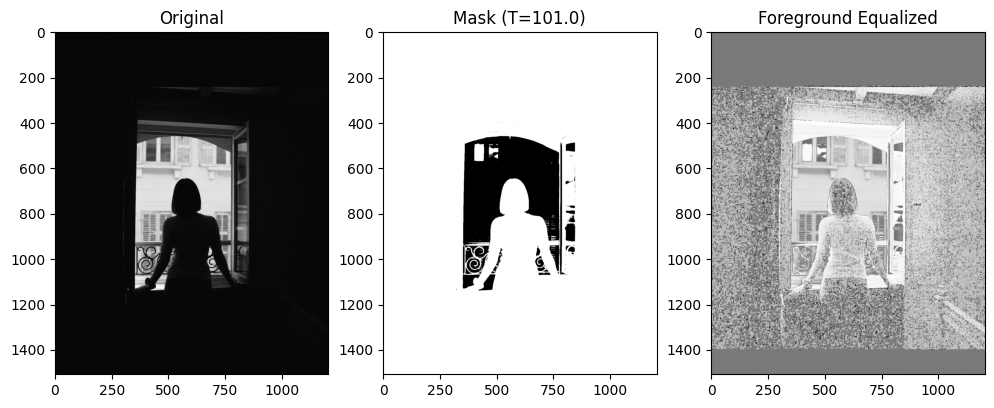

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load the image in grayscale
img = cv2.imread('/content/drive/MyDrive/Assignment1/looking_out.jpg', 0)

# 4(a) Otsu Thresholding
# We use THRESH_BINARY_INV because the foreground (woman) is darker than the background (window).
# This makes the woman/room white (255) in the mask.
thresh_val, mask = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

print(f"Otsu Threshold Value: {thresh_val}")

# 4(b) Histogram Equalization (Foreground Only)
# 1. Calculate histogram ONLY for masked pixels
hist = cv2.calcHist([img], [0], mask, [256], [0, 256])

# 2. Compute Cumulative Distribution Function (CDF) and normalize it
cdf = hist.cumsum()
cdf_normalized = (cdf * 255 / cdf.max()).astype('uint8')

# 3. Apply the CDF only to the masked region
# We use NumPy indexing to update only the foreground pixels
img_equalized = img.copy()
img_equalized[mask == 255] = cdf_normalized[img[mask == 255]]

# --- Visualization ---
plt.figure(figsize=(12, 5))
plt.subplot(131), plt.imshow(img, cmap='gray'), plt.title('Original')
plt.subplot(132), plt.imshow(mask, cmap='gray'), plt.title(f'Mask (T={thresh_val})')
plt.subplot(133), plt.imshow(img_equalized, cmap='gray'), plt.title('Foreground Equalized')
plt.show()